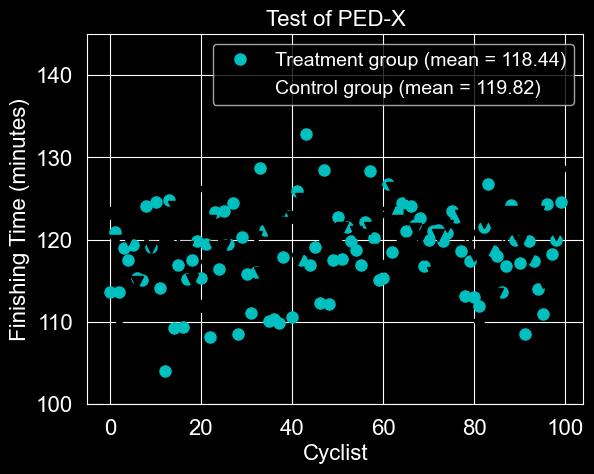

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

#set line width
plt.rcParams['lines.linewidth'] = 4
#set font size for titles
plt.rcParams['axes.titlesize'] = 16
#set font size for labels on axes
plt.rcParams['axes.labelsize'] = 16
#set size of num_bers on x-axis
plt.rcParams['xtick.labelsize'] = 16
#set size of num_bers on y-axis
plt.rcParams['ytick.labelsize'] = 16
#set size of ticks on x-axis
plt.rcParams['xtick.major.size'] = 7
#set size of ticks on y-axis
plt.rcParams['ytick.major.size'] = 7
#set size of markers, e.g., circles representing points
plt.rcParams['lines.markersize'] = 10
#set num_ber of _times marker is shown when displaying legend
plt.rcParams['legend.numpoints'] = 1
#Set size of type in legend
plt.rcParams['legend.fontsize'] = 14


# # Code used to generate data for Figure 21-1 on page 458
random.seed(148)
treatment_dist = (119.5, 5.0)
control_dist = (120, 4.0)
sample_size = 100
treatment_times, control_times = [], []
for s in range(sample_size):
    treatment_times.append(random.gauss(treatment_dist[0],
                                        treatment_dist[1]))
    control_times.append(random.gauss(control_dist[0],
                                      control_dist[1]))
control_mean = sum(control_times)/len(control_times)
treatment_mean = sum(treatment_times)/len(treatment_times)

plt.plot(treatment_times, 'co', markersize = 8,
        label = 'Treatment group (mean = ' +
        str(round(treatment_mean, 2)) + ')')
plt.plot(control_times, 'kv', markersize = 8,
        label = 'Control group (mean = ' +
        str(round(control_mean,2)) + ')')
plt.title('Test of PED-X')
plt.xlabel('Cyclist')
plt.ylabel('Finishing Time (minutes)')
plt.ylim(100, 145)
plt.legend()

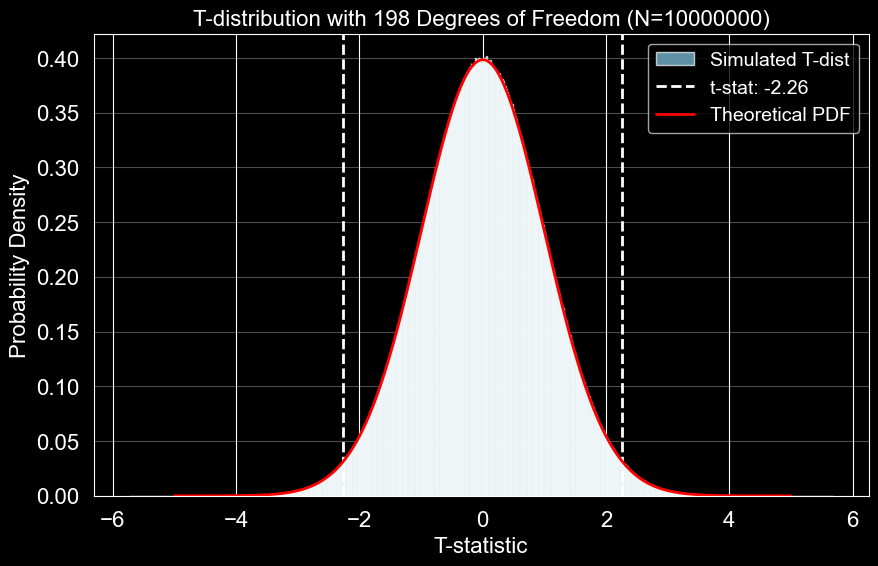

In [3]:
import scipy.stats


t_stat = -2.26
df = 198  # 자유도
num_samples = 10000000
num_bins = 1000

t_dist = np.random.standard_t(df, size=num_samples)


plt.figure(figsize=(10, 6))

plt.hist(t_dist, bins=num_bins, density=True, alpha=0.7, color='skyblue', label='Simulated T-dist')


plt.axvline(t_stat, color='white', linestyle='--', linewidth=2, label=f't-stat: {t_stat}')
plt.axvline(-t_stat, color='white', linestyle='--', linewidth=2)

x = np.linspace(-5, 5, 1000)
plt.plot(x, scipy.stats.t.pdf(x, df), 'r-', lw=2, label='Theoretical PDF')

plt.title(f'T-distribution with {df} Degrees of Freedom (N={num_samples})')
plt.xlabel('T-statistic')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [4]:
control_mean = round(sum(control_times) / len(control_times) , 2)
treatment_mean = round(sum(treatment_times) / len(treatment_times) , 2)

print(f'treatment_mean - control_mean = {round(treatment_mean - control_mean , 2)} min')

two_sample_test = scipy.stats.ttest_ind(treatment_times, control_times, equal_var= False)

print('The t-statistic from two-sample test is',
      round(two_sample_test[0], 2))
print('The p-value from two-sample test is',
      round(two_sample_test[1], 2))

treatment_mean - control_mean = -1.38 min
The t-statistic from two-sample test is -2.11
The p-value from two-sample test is 0.04


In [5]:
random.seed(100)
treatment_dist = (119.5 , 5.0)
control_dist = (120, 4.0)
sample_size = 100

treatment_times , control_times = [] , []

for i in range(sample_size):
    treatment_times.append(random.gauss(treatment_dist[0] , treatment_dist[1]))
    control_times.append(random.gauss(control_dist[0] , control_dist[1]))


In [7]:
num_game = 1273
lyndsay_wins = 666
num_trials = 10000
at_least = 0

for i in range(num_trials):
    l_wins , j_wins = 0 , 0

    for g in range(num_game):
        if random.random() < 0.5:
           l_wins += 1
        else:
            j_wins += 1

    if l_wins >= lyndsay_wins or j_wins >= lyndsay_wins:
        at_least += 1

print('Probability of result at least this',
      'extreme by accident =', at_least/num_trials)


Probability of result at least this extreme by accident = 0.1043


In [ ]:
num_games = 1273
lyndsay_wins = 666
num_trials = 10000
at_least = 0
for t in range(num_trials):
    l_wins, j_wins = 0, 0
    for g in range(num_games):
        if random.random() < 0.5:
            l_wins += 1
        else:
            j_wins += 1
    if l_wins >= lyndsay_wins or j_wins >= lyndsay_wins:
        at_least += 1
print('Probability of result at least this',
      'extreme by accident =', at_least/num_trials)

In [9]:
def get_BM_data(filename):

    data = {}
    f = open(filename)
    line = f.readline()
    data['name'], data['gender'], data['age'] = [], [], []
    data['division'], data['country'], data['time'] = [], [], []
    while line != '':
        split = line.split(',')
        data['name'].append(split[0])
        data['gender'].append(split[1])
        data['age'].append(int(split[2]))
        data['division'].append(int(split[3]))
        data['country'].append(split[4])
        data['time'].append(float(split[5][:-1]))
        line = f.readline()
    f.close()
    return data

data = get_BM_data('bm_results2012.csv')
countries_to_compare = ['BEL', 'BRA', 'FRA', 'JPN', 'ITA']

country_times = {}
for i in range(len(data['name'])): #for each racer
    if (data['country'][i] in countries_to_compare and
        data['gender'][i] == 'F'):
        try:
            country_times[data['country'][i]].append(data['time'][i])
        except KeyError:
            country_times[data['country'][i]] = [data['time'][i]]


for c1 in countries_to_compare:
    for c2 in countries_to_compare:
        if c1 < c2:
            pVal = scipy.stats.ttest_ind(country_times[c1],
                                    country_times[c2],
                                    equal_var = False)[1]
            if pVal < 0.05:
                print(c1, 'and', c2,
                      'have significantly different means,',
                      'p-value =', round(pVal, 4))


ITA and JPN have significantly different means, p-value = 0.025


In [12]:
num_hyps = 50
sample_size = 200
population = []

for i in range(5000):
    population.append(random.gauss(0,1))

sample1s , sample2s = [] , []

for i in range(num_hyps):
    sample1s.append(random.sample(population, sample_size))
    sample2s.append(random.sample(population, sample_size))


numsig = 0

for i in range(num_hyps):
    if scipy.stats.ttest_ind(sample1s[i], sample2s[i])[1] < 0.05:
        numsig += 1

print('# of statistically significantly different (p < 0.05) pairs  =',
        numsig)

# of statistically significantly different (p < 0.05) pairs  = 3
